# Quantum Boltzmann Machine

<em style="color:gray;">Copyright (c) 2026 QuAIR team. All Rights Reserved.</em>

This tutorial studies the idea of quantum Boltzmann machine and its application for ground-state energy estimation.
The goal is to optimize a parameterized Gibbs state so that its energy under a
target Hamiltonian becomes as small as possible.

**Table of Contents**
- [Classical Boltzmann distribution](#classical-boltzmann-distribution)
- [Boltzmann machine](#boltzmann-machine)
- [Quantum Boltzmann machine for ground-state energy estimation](#quantum-boltzmann-machine-for-ground-state-energy-estimation)
  - [Overview](#overview)
  - [Implementation](#implementation)
- [Extension: evolved quantum Boltzmann machines](#extension-evolved-quantum-boltzmann-machines)
- [References](#references)





In [1]:
from typing import Sequence, TypeAlias

import matplotlib.pyplot as plt
import torch

import quairkit as qkit
from quairkit import Circuit, Hamiltonian, State, to_state
from quairkit.database import *
from quairkit.qinfo import *

plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams["font.family"] = "STIXGeneral"



In [2]:
SEED = 910

qkit.set_dtype("complex128")
qkit.set_seed(SEED)

Coeff: TypeAlias = float
PauliString: TypeAlias = str
PauliTerm: TypeAlias = list[Coeff | PauliString]
PauliList: TypeAlias = list[PauliTerm]

## Classical Boltzmann distribution

A classical system with discrete states $i$ and scalar energies $E_i$ follows
the Boltzmann distribution in thermal equilibrium:
$$
p_i = \frac{e^{-\beta E_i}}{Z},
\qquad
\beta = \frac{1}{k_B T},
\qquad
Z = \sum_i e^{-\beta E_i}. \tag{1}
$$

Lower-energy states are exponentially more probable, so in the zero-temperature
limit the probability mass concentrates on the ground state.






## Boltzmann machine

A classical Boltzmann machine turns this energy-based viewpoint into a
trainable probabilistic model over visible and hidden binary units:
$$
E(v,h) = -v^\top W h - b^\top v - c^\top h. \tag{2}
$$

Training adjusts the parameters so that the model distribution matches the
data distribution. The main computational bottleneck is the partition
function, whose exact evaluation becomes intractable as the system grows.

A quantum Boltzmann machine (QBM) keeps the same Gibbs-state idea, but
replaces the scalar energy by a Hamiltonian.






The role of the QBM here is therefore different from the role of a classical
Boltzmann machine in generative modeling:
- A classical Boltzmann machine is trained to reproduce a data distribution.
- In this tutorial, the QBM is used as a **variational ansatz**. Its Gibbs
  state is optimized so that the energy under a target Hamiltonian becomes as
  small as possible.

So the quantity being optimized is not a likelihood, but the energy
expectation value $\textrm{Tr}(H \rho(\theta))$.






## Quantum Boltzmann machine for ground-state energy estimation

### Overview

In this tutorial, a QBM is used as a **variational mixed-state ansatz** for a
target Hamiltonian $H$. We introduce a learnable Hamiltonian
$$
G(\theta) = \sum_{j=1}^{J}\theta_j G_j,
\qquad
\rho(\theta) = \frac{e^{-G(\theta)}}{Z(\theta)},
\qquad
Z(\theta)=\operatorname{Tr}[e^{-G(\theta)}]. \tag{3}
$$

Here the inverse temperature can be absorbed into the scale of
$G(\theta)$, so the tutorial writes the Gibbs state directly in the form
$e^{-G(\theta)}/Z(\theta)$.
The quantity optimized by the QBM is the energy expectation value
$$
f(\theta)=\operatorname{Tr}[H\rho(\theta)]. \tag{4}
$$

This is the objective function that the tutorial is optimizing. The reason it
is relevant to ground-state estimation is the variational principle: $f(\theta)\ge E_0$,
where $E_0$ is the smallest eigenvalue of $H$. Therefore, lowering
$f(\theta)$ pushes the model state toward the ground-state energy of $H$.

It is useful to keep the following three objects separate:
- $H$: the fixed target Hamiltonian whose ground-state energy we want.
- $G(\theta)$: the learnable QBM Hamiltonian.
- $\rho(\theta)$: the Gibbs state induced by $G(\theta)$.

To make the gradient formula concrete, we fix the target Hamiltonian before
introducing the estimator. Throughout this tutorial, we use a 6-qubit
transverse-field Ising model (TFIM) with open boundary conditions,
$$
H
=
-J \sum_{i=0}^{n-2} Z_i Z_{i+1}
-h \sum_{i=0}^{n-1} X_i. \tag{5}
$$

This choice produces only three nearest-neighbor $ZZ$ terms and four local
$X$ terms, so the later sum over Hamiltonian terms can be evaluated exactly
instead of sampled.

### Implementation

We construct the target Hamiltonian and the Pauli basis for $G(\theta)$
upfront, because both objects appear repeatedly in the gradient estimator and
in the training loop below.



In [3]:
num_qubits = 6

def tfim_obc(
    num_qubits: int,
    coupling: float,
    field: float,
    open_boundary: bool = True,
) -> PauliList:
    r"""Construct the transverse-field Ising model in Pauli-list form.

    Args:
        num_qubits: Number of qubits in the spin chain.
        coupling: Coupling constant :math:`J` in the ZZ interaction term.
        field: Field strength :math:`h` in the transverse X term.
        open_boundary: Whether to use open boundary conditions. If ``False``,
            the last qubit is also coupled to the first one.

    Returns:
        A Pauli-list representation of the TFIM Hamiltonian.
    """
    pauli_terms: PauliList = []
    coupling_range = range(num_qubits - 1) if open_boundary else range(num_qubits)

    for i in coupling_range:
        j = (i + 1) % num_qubits
        pauli_terms.append([-coupling, f"Z{i},Z{j}"])

    for i in range(num_qubits):
        pauli_terms.append([-field, f"X{i}"])

    return pauli_terms

target_terms = tfim_obc(num_qubits=num_qubits, coupling=1.0, field=0.6)
target_hamiltonian = Hamiltonian(target_terms, compress=False)
target_matrix = target_hamiltonian.matrix
generator_terms = [[1.0, str(pauli_str)] for _, pauli_str in target_terms]
generator_hamiltonians = [Hamiltonian([term], compress=False) for term in generator_terms]
generator_mats = [generator_hamiltonian.matrix for generator_hamiltonian in generator_hamiltonians]
# Move each target-term sign into the observable so the controlled gate still
# acts on a Hermitian unitary.
target_weights = target_matrix.real.new_tensor([abs(float(coeff)) for coeff, _ in target_terms])
target_unitary_mats = [
    (1.0 if float(coeff) >= 0 else -1.0) * generator_mat
    for (coeff, _), generator_mat in zip(target_terms, generator_mats)
]

ground_energy = torch.linalg.eigvalsh(target_matrix).min().item()
print(f"Ground-state energy (exact eigvalsh): {ground_energy:.6f}")

Ground-state energy (exact eigvalsh): -5.770919


Patel et al. [3] derive the gradient in the form
$$
\frac{\partial f(\theta)}{\partial \theta_j}
= -\frac{1}{2}\operatorname{Tr}\!\left[\{H,\Phi_\theta(G_j)\}\rho(\theta)\right]
+ \operatorname{Tr}[H\rho(\theta)]\,\operatorname{Tr}[G_j\rho(\theta)], \tag{6}
$$
where
$$
\Phi_\theta(X)
= \int_{\mathbb{R}} dt\, p(t)\,
e^{-iG(\theta)t} X e^{iG(\theta)t}. \tag{7}
$$

The first term can be estimated by a Hadamard-test circuit, and the second
term is a product of expectation values.




This tutorial follows that decomposition, but makes two simulator-oriented
simplifications:
- The target Hamiltonian is a $n$-qubit TFIM with only $2n-1$ Pauli
  terms, so we **sum over all Hamiltonian terms exactly** instead of sampling
  a Hamiltonian term index.
- We use `output.probability` and `State.expec_val(...)` to compute exact
  expectations on the simulator, instead of converting those probabilities
  into extra Bernoulli samples.

These choices make the demo shorter, more stable, and easier to read. For
larger Hamiltonians or shot-based backends, the Monte Carlo form of quantum Boltzmann gradient estimator (QBGE)
remains the scalable strategy.






With the concrete TFIM fixed, we use the following naming convention
throughout the implementation:
- `target_terms`: the Pauli decomposition of the fixed Hamiltonian $H$.
- `generator_terms`: the Pauli basis used to build the learnable Hamiltonian
  $G(\theta)$. In this demo, we reuse the same Pauli strings as
  `target_terms`, but with learnable coefficients. This is a tutorial choice,
  not a requirement of the general QBM framework.
- `target_weights`: the non-negative coefficients $\alpha_k$ in
  $H = \sum_k \alpha_k H_k$.
- `target_unitary_mats`: the signed matrices for the observables $H_k$, each
  equal to $\pm G_j$, so they can enter the controlled circuit directly.
- `model_hamiltonian`: the matrix form of the current $G(\theta)$.
- `rho_theta`: the density matrix form of the current Gibbs state.
- `rho_state`: the same Gibbs state wrapped as a QuAIRKit `State`, so we can
  use `State.expec_val(...)`.






In [4]:
def replace_coeffs(pauli_list: PauliList, new_coeffs: torch.Tensor) -> PauliList:
    r"""Return a copy of ``pauli_list`` with updated coefficients.

    Args:
        pauli_list: Input Pauli terms whose strings remain unchanged.
        new_coeffs: One-dimensional tensor of new coefficients.

    Returns:
        A new Pauli list with the same Pauli strings as ``pauli_list`` and the
        coefficients supplied by ``new_coeffs``.

    Raises:
        ValueError: If ``new_coeffs`` is not one-dimensional or has a mismatched
            length.
    """
    if new_coeffs.ndim != 1:
        raise ValueError(f"Expected a 1D tensor, but received shape {tuple(new_coeffs.shape)}.")
    if len(pauli_list) != len(new_coeffs):
        raise ValueError(
            f"The coefficient count {len(new_coeffs)} does not match the number "
            f"of Pauli terms {len(pauli_list)}."
        )

    coeffs = new_coeffs.detach().cpu().tolist()
    return [[float(coeff), pauli_list[idx][1]] for idx, coeff in enumerate(coeffs)]


def gibbs_state(model_hamiltonian: torch.Tensor) -> torch.Tensor:
    r"""Compute the Gibbs state generated by a Hamiltonian matrix.

    Args:
        model_hamiltonian: Matrix representation of :math:`G(\theta)`.

    Returns:
        The density matrix
        :math:`\rho(\theta)=e^{-G(\theta)}/\operatorname{Tr}[e^{-G(\theta)}]`.
    """
    gibbs_numerator = torch.linalg.matrix_exp(-model_hamiltonian)
    partition_function = torch.trace(gibbs_numerator).real
    return gibbs_numerator / partition_function

The integral over the time variable $t$ is still estimated by Monte Carlo,
because that is the genuinely large or continuous part of the QBGE.
The Hamiltonian-term sum, however, is evaluated exactly in this tutorial.
We also form the Gibbs state by direct matrix exponentiation, because the
whole workflow here is a simulator-side teaching demo. In the scalable QBM
setting discussed in Patel et al. [3], one assumes access to thermal-state
samples rather than constructing the full density matrix explicitly.

#### Sampling the evolution parameter $t$

Patel et al. [3] define the time-sampling density through the channel
$\Phi_\theta$ in Eq. (7). The probability density is
$$
p(t)=\frac{2}{\pi}\log\left|\coth\frac{\pi t}{2}\right|. \tag{8}
$$

For implementation, it is convenient to rewrite this density as a mixture of
exponential distributions,
$$
p(t)
= \sum_{k=0}^{\infty} w_k \lambda_k e^{-\lambda_k |t|},
\qquad
\lambda_k = (2k+1)\pi,
\qquad
w_k = \frac{8}{\pi^2(2k+1)^2}. \tag{9}
$$

The helper below samples $t$ by
1. drawing an exponential component index $k$,
2. sampling a positive magnitude from that component,
3. assigning a random sign.

This is the only place where the tutorial still uses Monte Carlo randomness in
the gradient estimator.






In [5]:
def sample_time_parameters(
    num_samples: int,
    reference: torch.Tensor,
    kmax: int = 200,
) -> torch.Tensor:
    r"""Sample time values from the QBGE density ``p(t)``.

    The density
    :math:`p(t)=\frac{2}{\pi}\log\left|\coth(\pi t / 2)\right|`
    can be sampled from a mixture of exponential distributions.

    Args:
        num_samples: Number of time samples to draw.
        reference: Tensor whose real dtype and device are reused for sampling.
        kmax: Truncation level of the exponential mixture.

    Returns:
        A one-dimensional tensor containing signed samples of ``t``.
    """
    component_idx = torch.arange(
        kmax + 1,
        dtype=reference.real.dtype,
        device=reference.device,
    )
    weights = 8.0 / (torch.pi**2 * (2 * component_idx + 1) ** 2)
    weights = weights / weights.sum()
    rates = (2 * component_idx + 1) * torch.pi

    chosen_components = torch.multinomial(weights, num_samples=num_samples, replacement=True)
    chosen_rates = rates[chosen_components]
    uniform_samples = torch.rand(
        num_samples,
        dtype=component_idx.dtype,
        device=component_idx.device,
    ).clamp_min(1e-12)
    magnitudes = -torch.log(uniform_samples) / chosen_rates
    signs = torch.where(
        torch.rand(num_samples, dtype=component_idx.dtype, device=component_idx.device) < 0.5,
        torch.ones(num_samples, dtype=component_idx.dtype, device=component_idx.device),
        -torch.ones(num_samples, dtype=component_idx.dtype, device=component_idx.device),
    )
    return magnitudes * signs

def batched_time_evolution(generator: torch.Tensor, times: torch.Tensor) -> torch.Tensor:
    r"""Return a batch of unitaries ``exp(-i t G)`` for a Hermitian generator.

    Args:
        generator: Hermitian matrix :math:`G(\theta)`.
        times: One-dimensional tensor of evolution times.

    Returns:
        A tensor of shape ``[len(times), dim, dim]`` containing the unitary
        evolutions corresponding to every value in ``times``.
    """
    eigvals, eigvecs = torch.linalg.eigh(generator)
    phases = torch.exp((-1j) * times[:, None] * eigvals[None, :])
    eigvecs_dag = eigvecs.conj().transpose(-2, -1)
    return eigvecs.unsqueeze(0) @ torch.diag_embed(phases.to(generator.dtype)) @ eigvecs_dag.unsqueeze(0)

#### First gradient term: Hadamard-test circuit

The first term in the QBM gradient is
$$
-\frac{1}{2}\operatorname{Tr}\!\left[\{H,\Phi_\theta(G_j)\}\rho(\theta)\right].
\tag{10}
$$

Expanding $H = \sum_k \alpha_k H_k$ gives
$$
-\sum_k \alpha_k \int_{\mathbb{R}} dt\, p(t)
\left(
\frac{1}{2}\operatorname{Tr}\!\left[
\left(U_{jk}(\theta,t)+U_{jk}^\dagger(\theta,t)\right)\rho(\theta)
\right]
\right). \tag{11}
$$

In the circuit picture, $U_{jk}(\theta,t)$ is the effective interference term
produced by the sequence controlled-$G_j$ → $e^{-iG(\theta)t}$ →
controlled-$H_k$.

The paper samples both the Hamiltonian index $k$ and the time variable $t$.
In this tutorial, we keep the Monte Carlo sampling over $t$, but replace the
outer sum over $k$ by an exact sum because the 4-qubit TFIM has only seven
terms. This keeps the same target quantity while removing one source of
variance.

As in the standard Hadamard test, the ancilla probability difference
$p(0) - p(1)$ equals the real part of the overlap term, so reading
`output.probability` is enough for the simulator implementation.

The circuit below therefore:
1. prepares $\ket{0}\bra{0} \otimes \rho(\theta)$,
2. applies a Hadamard on the ancilla,
3. applies controlled-$G_j$,
4. applies the batched evolution $e^{-iG(\theta)t}$,
5. applies controlled-$H_k$,
6. applies a final Hadamard and reads out the ancilla probability.



In [6]:
def estimate_grad_term1_circuit(
    target_weights: torch.Tensor,
    target_unitary_mats: Sequence[torch.Tensor],
    generator_mat: torch.Tensor,
    evolution_batch: torch.Tensor,
    circuit_input: State,
    system_dim: list[int],
) -> float:
    r"""Estimate the first QBM gradient term with a Hadamard-test circuit.

    Args:
        target_weights: Non-negative coefficients in the decomposition
            :math:`H=\sum_k \alpha_k H_k`.
        target_unitary_mats: Hermitian-unitary matrices representing the signed
            observables :math:`H_k`.
        generator_mat: Matrix of the basis operator :math:`G_j`.
        evolution_batch: Batch of unitaries ``exp(-i t G(theta))``.
        circuit_input: Input state ``|0><0| \otimes \rho(\theta)``.
        system_dim: Mixed system dimensions for the ancilla-system register.

    Returns:
        An estimate of
        :math:`-\frac{1}{2}\operatorname{Tr}[\{H,\Phi_\theta(G_j)\}\rho(\theta)]`.

    Note:
        The original QBGE algorithm samples a Hamiltonian term index and then a
        measurement bit. Here we only sample the time variable ``t``. The sum
        over Hamiltonian terms is exact, and the ancilla expectation is computed
        directly from ``output.probability``.
    """
    sample_contributions = []

    for coeff, target_unitary in zip(target_weights, target_unitary_mats):
        cir = Circuit(2, system_dim=system_dim)
        cir.h(0)
        cir.oracle(generator_mat, [0, 1], control_idx=1, latex_name=r"G_j")
        cir.oracle(evolution_batch, [1], latex_name=r"e^{-iG(\theta)t}")
        cir.oracle(target_unitary, [0, 1], control_idx=1, latex_name=r"H_k")
        cir.h(0)
        cir.measure(system_idx=[0])

        output_state = cir(circuit_input)
        probabilities = output_state.probability.real.clamp_min(0)
        probabilities = probabilities / probabilities.sum(dim=-1, keepdim=True)
        ancilla_z_expectation = probabilities[..., 0] - probabilities[..., 1]
        sample_contributions.append((-coeff) * ancilla_z_expectation)

    first_term_samples = torch.stack(sample_contributions, dim=0).sum(dim=0)
    return first_term_samples.mean().item()

#### Second gradient term: exact expectation product

The second term in Eq. (6) is
$$
\operatorname{Tr}[H\rho(\theta)]\,\operatorname{Tr}[G_j\rho(\theta)].
\tag{12}
$$

In the paper, this product is estimated from sampled measurement outcomes on
two copies of the Gibbs state. On the simulator, we can compute both
expectation values directly, so the Bernoulli product estimator is replaced by
its exact expectation. This is again a tutorial-oriented simplification.



In [7]:
def estimate_grad_term2_exact(
    energy_expectation: float,
    generator_hamiltonian: Hamiltonian,
    rho_state: State,
) -> float:
    r"""Compute the second QBM gradient term exactly.

    Args:
        energy_expectation: The exact energy :math:`\operatorname{Tr}[H\rho(\theta)]`.
        generator_hamiltonian: Single basis operator :math:`G_j`.
        rho_state: Current QBM Gibbs state.

    Returns:
        The exact value of
        :math:`\operatorname{Tr}[H\rho(\theta)]\operatorname{Tr}[G_j\rho(\theta)]`.

    Note:
        Because the simulator gives exact expectation values, the Bernoulli
        product estimator from the paper is replaced by the exact product of two
        expectations in this tutorial.
    """
    generator_expectation = rho_state.expec_val(generator_hamiltonian).real.item()
    return energy_expectation * generator_expectation

#### Assemble the full gradient

For each basis operator $G_j$, we evaluate the first term with the
Hadamard-test circuit and the second term as an exact product of
expectations. The resulting vector is the simulator-friendly QBM gradient used
throughout the rest of the tutorial.



In [8]:
def estimate_gradient(
    model_hamiltonian: torch.Tensor,
    rho_theta: torch.Tensor,
    rho_state: State,
    num_time_samples: int,
) -> torch.Tensor:
    r"""Estimate the QBM gradient for all parameters.

    Args:
        model_hamiltonian: Current QBM Hamiltonian matrix ``G(theta)``.
        rho_theta: Current Gibbs density matrix.
        rho_state: Current Gibbs state wrapped as a QuAIRKit ``State``.
        num_time_samples: Number of Monte Carlo samples for the time variable
            ``t``.

    Returns:
        A tensor containing the estimated gradient components.
    """
    energy_expectation = rho_state.expec_val(target_hamiltonian).real.item()
    sampled_times = sample_time_parameters(
        num_samples=num_time_samples,
        reference=model_hamiltonian,
    )
    evolution_batch = batched_time_evolution(model_hamiltonian, sampled_times)
    circuit_input = nkron(zero_state(1), to_state(rho_theta, system_dim=2**num_qubits))
    system_dim = [2, int(rho_theta.shape[0])]

    gradient_components = []
    for generator_hamiltonian, generator_mat in zip(generator_hamiltonians, generator_mats):
        first_term = estimate_grad_term1_circuit(
            target_weights=target_weights,
            target_unitary_mats=target_unitary_mats,
            generator_mat=generator_mat,
            evolution_batch=evolution_batch,
            circuit_input=circuit_input,
            system_dim=system_dim,
        )
        second_term = estimate_grad_term2_exact(
            energy_expectation=energy_expectation,
            generator_hamiltonian=generator_hamiltonian,
            rho_state=rho_state,
        )
        gradient_components.append(first_term + second_term)

    return model_hamiltonian.real.new_tensor(gradient_components)

The rest of the workflow is classical: initialize $\theta$, estimate the
gradient, update the parameters, rebuild $G(\theta)$, and track the energy
trajectory. The helper below chooses a learning rate using the same kind of
smoothness-inspired scaling that appears in the QBM analysis.






#### Training loop

Once the gradient estimator is available, the optimization loop is standard:
1. initialize $\theta$,
2. construct $G(\theta)$ and $\rho(\theta)$,
3. estimate the QBM gradient,
4. update $\theta$ with gradient descent,
5. record the energy trajectory.

We keep the paper-inspired smoothness scaling for the learning rate, but use a
smaller system size and fewer optimization steps so that the tutorial remains
lightweight enough to run quickly.






In [9]:
def max_op_norm(term_mats: Sequence[torch.Tensor]) -> float:
    r"""Return the maximum spectral norm of a list of matrices.

    Args:
        term_mats: Input matrices.

    Returns:
        The largest operator norm among all matrices in ``term_mats``.
    """
    return torch.stack([torch.linalg.eigvalsh(mat).abs().max() for mat in term_mats]).max().item()


def train_qbm_ground_state_energy(
    theta: torch.Tensor,
    num_qubits: int,
    num_epochs: int,
    num_time_samples: int,
) -> tuple[torch.Tensor, list[float]]:
    r"""Train a QBM Gibbs ansatz for ground-state energy estimation.

    Args:
        theta: Initial parameter vector.
        num_qubits: Number of qubits in the QBM instance.
        num_epochs: Number of gradient-descent iterations.
        num_time_samples: Number of time samples used in the first gradient term.

    Returns:
        A tuple ``(theta_final, energy_trajectory)``.
    """
    num_generators = len(generator_mats)
    alpha_l1 = target_weights.sum().item()
    max_generator_norm = max_op_norm(generator_mats)
    smoothness_rate = (
        2.0
        * (2.0**0.5)
        * (num_generators**0.75)
        * (alpha_l1**0.5)
        * max_generator_norm
    )
    learning_rate = 20.0 / smoothness_rate

    model_terms = replace_coeffs(generator_terms, theta)
    model_hamiltonian = Hamiltonian(model_terms, compress=False).matrix
    rho_theta = gibbs_state(model_hamiltonian)
    rho_state = to_state(rho_theta, system_dim=[2] * num_qubits)
    energy_trajectory = [rho_state.expec_val(target_hamiltonian).real.item()]

    for _ in range(num_epochs):
        gradient_estimate = estimate_gradient(
            model_hamiltonian=model_hamiltonian,
            rho_theta=rho_theta,
            rho_state=rho_state,
            num_time_samples=num_time_samples,
        )
        theta = theta - learning_rate * gradient_estimate

        model_terms = replace_coeffs(generator_terms, theta)
        model_hamiltonian = Hamiltonian(model_terms, compress=False).matrix
        rho_theta = gibbs_state(model_hamiltonian)
        rho_state = to_state(rho_theta, system_dim=[2] * num_qubits)
        energy_trajectory.append(rho_state.expec_val(target_hamiltonian).real.item())

    return theta, energy_trajectory

We now compare several values of the number
of sampled time points in the first QBGE term.






In [10]:
num_epochs = 30
num_time_samples = 5

In [11]:
theta_initial = torch.randn(len(generator_terms), dtype=target_weights.dtype, device=target_weights.device)

theta_final, energy_trajectory = train_qbm_ground_state_energy(
    theta=theta_initial,
    num_qubits=num_qubits,
    num_epochs=num_epochs,
    num_time_samples=num_time_samples,
)

Increasing ``num_time_samples`` reduces the Monte Carlo noise associated with
the integral over ``t``. In this tutorial, that is the only remaining Monte
Carlo dimension: the Hamiltonian-term sum and the readout expectation are both
evaluated exactly on the simulator.






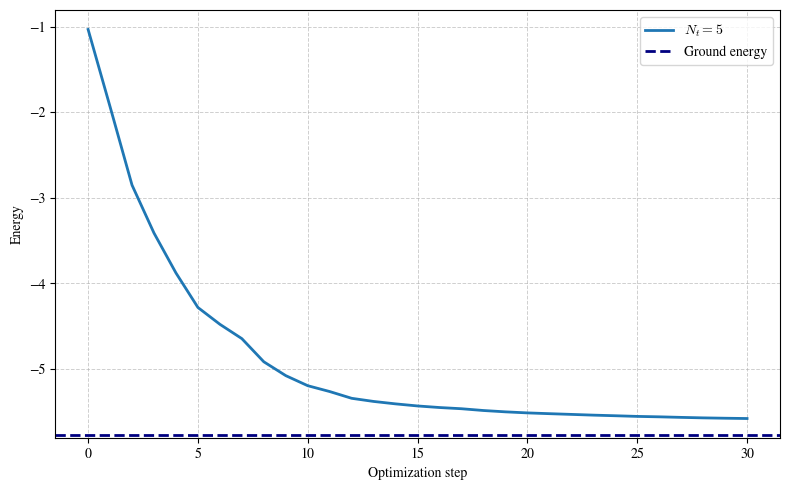

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(list(range(num_epochs + 1)), energy_trajectory, linewidth=2.0, label=fr"$N_t={num_time_samples}$")

plt.axhline(
    y=ground_energy,
    linestyle="--",
    linewidth=2.0,
    color="navy",
    label="Ground energy",
)
plt.xlabel("Optimization step")
plt.ylabel("Energy")
plt.grid(True, which="both", linestyle="--", linewidth=0.7, alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

The energy curves should move downward toward the exact ground-state energy.
The final gap still depends on the ansatz, the initialization, and the number
of sampled time values. The important tutorial point is that the QBM is
optimizing the energy function $\textrm{Tr}(H \rho(\theta))$, and that the gradient can
be decomposed into a Hadamard-test term plus an expectation-product term.




## Extension: evolved quantum Boltzmann machines

The QBM above follows Patel et al. [3]. A later extension, the evolved
quantum Boltzmann machine (EQBM) of Minervini et al. [4], appends a
learnable unitary layer
$$
U(\boldsymbol{\phi}) = e^{-iH(\boldsymbol{\phi})},
\qquad
H(\boldsymbol{\phi}) = \sum_{k=1}^{n}\phi_k Y_k,
$$
Here, $Y_k$ denotes the Pauli-$Y$ operator acting on qubit $k$, and
$\phi_k$ is the corresponding real-valued rotation parameter. In other
words, the $\boldsymbol{\phi}$-parameters control an extra variational
layer built from single-qubit local $Y$-rotations, while the
$\boldsymbol{\theta}$-parameters still determine the underlying Gibbs state.


So the evolved state is
$
\omega(\boldsymbol{\theta},\boldsymbol{\phi})
\;=\;
U(\boldsymbol{\phi})\,\rho(\boldsymbol{\theta})\,U(\boldsymbol{\phi})^\dagger.
$ And we optimize the energy
$
E(\boldsymbol{\theta},\boldsymbol{\phi})
= \operatorname{Tr}[O\,\omega(\boldsymbol{\theta},\boldsymbol{\phi})].$

Setting $\phi = 0$ recovers the original QBM. We do not implement the full
EQBM training loop here, because that would require an additional gradient
estimator for the $\phi$ parameters. The purpose of this section is only to
show how the QBM ansatz is extended in the follow-up work.






## References
[1] Ackley, David H., Geoffrey E. Hinton, and Terrence J. Sejnowski.
"A learning algorithm for Boltzmann machines." Cognitive science 9.1 (1985):
147-169.

[2] Marullo, Chiara, and Elena Agliari. "Boltzmann machines as generalized
Hopfield networks: a review of recent results and outlooks." Entropy 23.1
(2020): 34.

[3] Patel, Dhrumil, Daniel Koch, Saahil Patel, and Mark M. Wilde.
"Quantum Boltzmann machine learning of ground-state energies."
arXiv preprint arXiv:2410.12935 (2024).

[4] Minervini, Michele, Dhrumil Patel, and Mark M. Wilde.
"Evolved Quantum Boltzmann Machines."
arXiv preprint arXiv:2501.03367 (2025).






*Table: A reference of notation conventions in this tutorial.*

|      Symbol       | Description                                                   |
|:-----------------:|---------------------------------------------------------------|
|      $H$,$G$      | Hamiltonian                                                   |
| $\alpha$,$\theta$ | Parameters for Hamiltonian H and G respectively                |
|        $f$        | Energy, loss function                                         |
|  $\rho(\theta)$  | Gibbs state                                                   |

In [13]:
qkit.print_info()


---------VERSION---------
quairkit: 0.5.0
torch: 2.8.0+cpu
numpy: 2.2.6
scipy: 1.15.3
matplotlib: 3.10.6
---------SYSTEM---------
Python version: 3.10.18
OS: Windows
OS version: 10.0.26100
---------DEVICE---------
CPU: ARMv8 (64-bit) Family 8 Model 1 Revision 201, Qualcomm Technologies Inc
